# Projeto 09 — TSP com diferentes algoritmos de otimização
**Aula 9 — Algoritmos e Programação (IA para Engenheiros - UFRGS)**

Resolve benchmarks da **TSPLIB95** usando, trajeto a trajeto:
1. **Nearest Neighbor** (guloso)
2. **2-opt** (busca local)
3. **Algoritmo Genético** (Order Crossover + swap mutation + torneio + elitismo)

Cada algoritmo produz seu próprio tour, que é então plotado no estilo do slide 27.

## 1. Imports e configuração

In [ ]:
# pip install tsplib95 matplotlib
import os
import random
import time

import tsplib95
import matplotlib.pyplot as plt

random.seed(42)
PASTA = os.getcwd()
print('Pasta de trabalho:', PASTA)

Pasta de trabalho: c:\Users\mmm\OneDrive\UFRGS\45946 - Algoritmos E Programação\Projetos\Projeto09


## 2. Funções utilitárias
Carregamento do `.tsp`, cálculo de distância de um tour, e plot do trajeto no estilo do slide 27.

In [ ]:
def carregar_problema(arquivo):
    prob = tsplib95.load(arquivo)
    nos = list(prob.get_nodes())
    n = len(nos)
    # matriz de distâncias pré-calculada (acelera o AG)
    dist = [[0.0] * n for _ in range(n)]
    for i, a in enumerate(nos):
        for j, b in enumerate(nos):
            if i != j:
                dist[i][j] = prob.get_weight(a, b)
    coords = {i: prob.node_coords[nos[i]] for i in range(n)}
    return prob, nos, n, dist, coords

def tour_distancia(tour, dist):
    n = len(tour)
    return sum(dist[tour[i]][tour[(i + 1) % n]] for i in range(n))

def plotar_tour(tour, coords, dist, titulo):
    fig, ax = plt.subplots(figsize=(8, 6))
    xs = [coords[i][1] for i in tour] + [coords[tour[0]][1]]
    ys = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    ax.plot(xs, ys, color='#534AB7', linewidth=1.5, label='Tour', zorder=2)
    for i, (lat, lon) in coords.items():
        ax.scatter(lon, lat, s=80, color='#5DCAA5',
                   edgecolors='#1F4D3D', zorder=3)
        ax.annotate(str(i + 1), (lon, lat),
                    textcoords='offset points', xytext=(6, 6), fontsize=8)
    d = tour_distancia(tour, dist)
    ax.set_title(f'{titulo}  —  distância = {d:.2f}')
    ax.set_xlabel('Longitude / x')
    ax.set_ylabel('Latitude / y')
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.legend()
    plt.show()
    return d

## 3. Carregar o benchmark `burma14` (slide 27)

In [ ]:
prob, nos, n, dist, coords = carregar_problema(os.path.join(PASTA, 'burma14.tsp'))
print(f'Dimensão: {n} cidades  |  tipo: {prob.edge_weight_type}')
print(f'Ótimo conhecido (TSPLIB): 3323')

Dimensão: 14 cidades  |  tipo: GEO
Ótimo conhecido (TSPLIB): 3323


## 4. Trajeto 1 — Nearest Neighbor (guloso)
Em cada passo, vai à cidade não-visitada mais próxima.

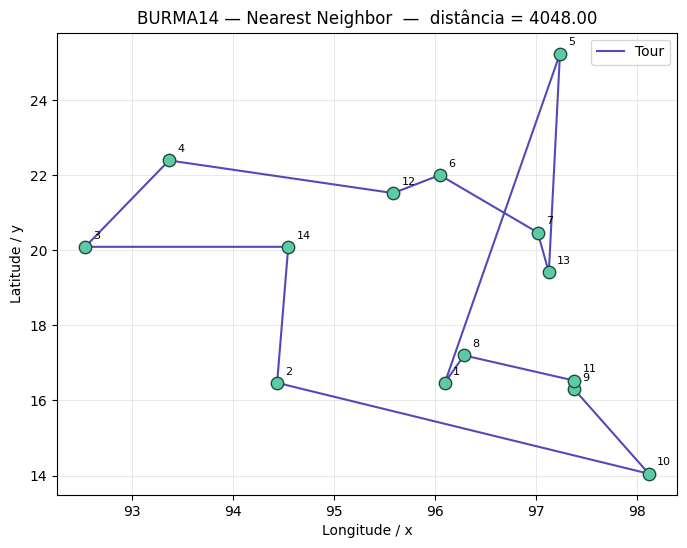

Tempo: 0.09 ms   |   gap vs ótimo: 21.82%


In [ ]:
def nearest_neighbor(n, dist, inicio=0):
    visitados = [False] * n
    tour = [inicio]
    visitados[inicio] = True
    atual = inicio
    for _ in range(n - 1):
        proximo, menor = -1, float('inf')
        for j in range(n):
            if not visitados[j] and dist[atual][j] < menor:
                menor, proximo = dist[atual][j], j
        tour.append(proximo)
        visitados[proximo] = True
        atual = proximo
    return tour

t0 = time.perf_counter()
tour_nn = nearest_neighbor(n, dist)
t_nn = time.perf_counter() - t0
d_nn = plotar_tour(tour_nn, coords, dist, 'BURMA14 — Nearest Neighbor')
print(f'Tempo: {t_nn*1000:.2f} ms   |   gap vs ótimo: {(d_nn-3323)/3323*100:.2f}%')

## 5. Trajeto 2 — 2-opt (busca local)
Parte do tour do NN e troca arestas até não haver mais melhoria possível.

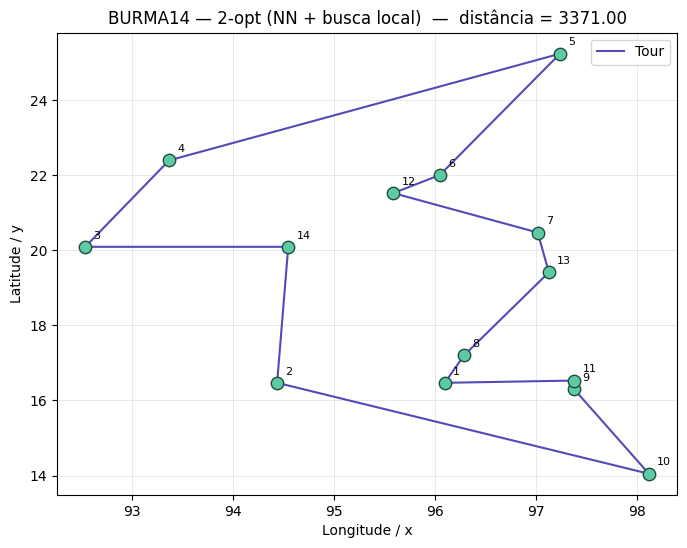

Tempo: 0.13 ms   |   gap vs ótimo: 1.44%


In [ ]:
def dois_opt(tour, dist, max_iter=10_000):
    n = len(tour)
    melhor = tour[:]
    melhorou = True
    it = 0
    while melhorou and it < max_iter:
        melhorou = False
        it += 1
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                a, b = melhor[i - 1], melhor[i]
                c, d = melhor[j], melhor[(j + 1) % n]
                delta = (dist[a][c] + dist[b][d]) - (dist[a][b] + dist[c][d])
                if delta < -1e-9:
                    melhor[i:j + 1] = melhor[i:j + 1][::-1]
                    melhorou = True
    return melhor

t0 = time.perf_counter()
tour_2opt = dois_opt(tour_nn, dist)
t_2opt = time.perf_counter() - t0
d_2opt = plotar_tour(tour_2opt, coords, dist, 'BURMA14 — 2-opt (NN + busca local)')
print(f'Tempo: {t_2opt*1000:.2f} ms   |   gap vs ótimo: {(d_2opt-3323)/3323*100:.2f}%')

## 6. Trajeto 3 — Algoritmo Genético
Indivíduo = permutação de cidades. Operadores:
- **Seleção**: torneio (k=3)
- **Crossover**: *Order Crossover* (OX) — preserva permutações válidas
- **Mutação**: swap (troca duas posições)
- **Elitismo**: os 2 melhores passam direto

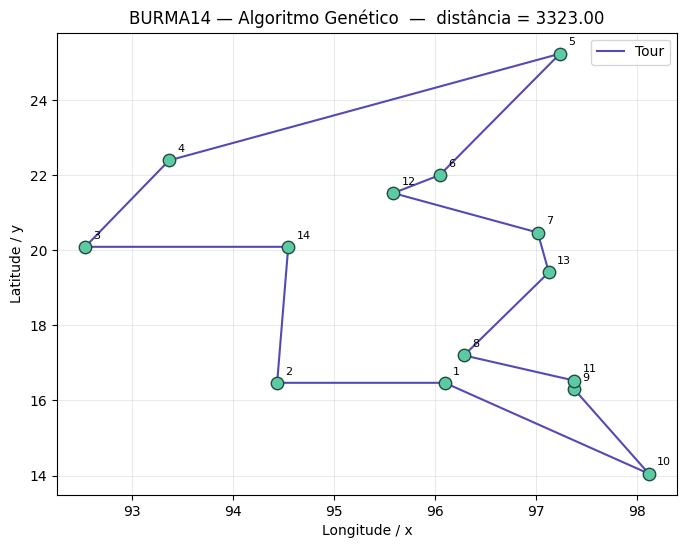

Tempo: 2.56 s   |   gap vs ótimo: 0.00%


In [ ]:
def torneio(pop, fits, k=3):
    cand = random.sample(list(zip(pop, fits)), k)
    return min(cand, key=lambda x: x[1])[0]

def ox_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    filho = [-1] * n
    filho[a:b + 1] = p1[a:b + 1]
    resto = [g for g in p2 if g not in filho]
    k = 0
    for i in range(n):
        if filho[i] == -1:
            filho[i] = resto[k]
            k += 1
    return filho

def mut_swap(ind, taxa=0.02):
    ind = ind[:]
    for i in range(len(ind)):
        if random.random() < taxa:
            j = random.randrange(len(ind))
            ind[i], ind[j] = ind[j], ind[i]
    return ind

def algoritmo_genetico(n, dist, pop_size=100, geracoes=400,
                       taxa_cx=0.9, taxa_mut=0.02, elitismo=2,
                       semeado_nn=True):
    base = list(range(n))
    pop = [random.sample(base, n) for _ in range(pop_size)]
    if semeado_nn:
        for k in range(min(n, max(1, pop_size // 10))):
            pop[k] = nearest_neighbor(n, dist, inicio=k)
    hist_melhor, hist_medio = [], []
    for _ in range(geracoes):
        fits = [tour_distancia(ind, dist) for ind in pop]
        hist_melhor.append(min(fits))
        hist_medio.append(sum(fits) / pop_size)
        ordem = sorted(range(pop_size), key=lambda i: fits[i])
        nova_pop = [pop[i] for i in ordem[:elitismo]]
        while len(nova_pop) < pop_size:
            p1 = torneio(pop, fits)
            p2 = torneio(pop, fits)
            filho = ox_crossover(p1, p2) if random.random() < taxa_cx else p1[:]
            nova_pop.append(mut_swap(filho, taxa_mut))
        pop = nova_pop
    fits = [tour_distancia(ind, dist) for ind in pop]
    melhor = pop[min(range(pop_size), key=lambda i: fits[i])]
    return melhor, hist_melhor, hist_medio

random.seed(42)
t0 = time.perf_counter()
tour_ag, hist_m, hist_a = algoritmo_genetico(n, dist,
                                             pop_size=120, geracoes=400)
t_ag = time.perf_counter() - t0
d_ag = plotar_tour(tour_ag, coords, dist, 'BURMA14 — Algoritmo Genético')
print(f'Tempo: {t_ag:.2f} s   |   gap vs ótimo: {(d_ag-3323)/3323*100:.2f}%')

## 7. Curva de convergência do AG (burma14)

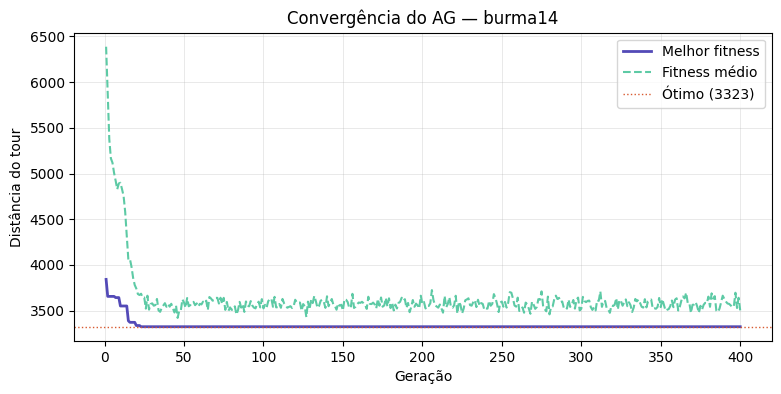

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
geracoes = range(1, len(hist_m) + 1)
ax.plot(geracoes, hist_m, color='#534AB7', linewidth=2, label='Melhor fitness')
ax.plot(geracoes, hist_a, color='#5DCAA5', linewidth=1.5, linestyle='--',
        label='Fitness médio')
ax.axhline(3323, color='#D85A30', linewidth=1, linestyle=':',
           label='Ótimo (3323)')
ax.set_xlabel('Geração')
ax.set_ylabel('Distância do tour')
ax.set_title('Convergência do AG — burma14')
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend()
plt.show()

## 8. Tabela comparativa — burma14

In [ ]:
OTIMO_BURMA14 = 3323
resultados_burma14 = [
    ('Nearest Neighbor', d_nn,   t_nn),
    ('2-opt (NN + LS)',  d_2opt, t_2opt),
    ('Algoritmo Genético', d_ag, t_ag),
]
print(f"{'Algoritmo':<22}{'Distância':>12}{'Tempo (s)':>12}{'Gap (%)':>10}")
print('-' * 56)
for nm, d, t in resultados_burma14:
    gap = (d - OTIMO_BURMA14) / OTIMO_BURMA14 * 100
    print(f'{nm:<22}{d:>12.2f}{t:>12.3f}{gap:>10.2f}')
print('-' * 56)
print(f"{'Ótimo conhecido':<22}{OTIMO_BURMA14:>12}")

Algoritmo                Distância   Tempo (s)   Gap (%)
--------------------------------------------------------
Nearest Neighbor           4048.00       0.000     21.82
2-opt (NN + LS)            3371.00       0.000      1.44
Algoritmo Genético         3323.00       2.562      0.00
--------------------------------------------------------
Ótimo conhecido               3323


---
## 9. Repetindo no benchmark `berlin52`
Mesmo procedimento, agora com 52 cidades. Ótimo TSPLIB = **7542**.

In [ ]:
prob_b, nos_b, n_b, dist_b, coords_b = carregar_problema(os.path.join(PASTA, 'berlin52.tsp'))
print(f'Dimensão: {n_b} cidades  |  tipo: {prob_b.edge_weight_type}')
OTIMO_BERLIN52 = 7542

Dimensão: 52 cidades  |  tipo: EUC_2D


### 9.1 Trajeto 1 — Nearest Neighbor

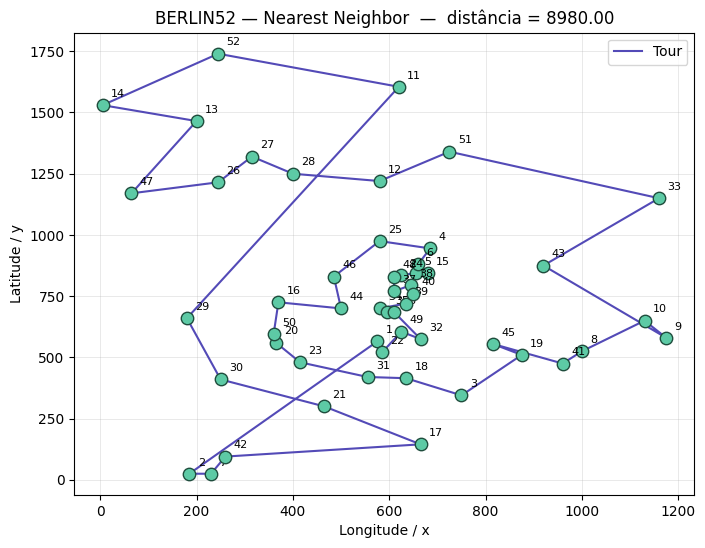

Tempo: 0.68 ms   |   gap vs ótimo: 19.07%


In [ ]:
t0 = time.perf_counter()
tour_nn_b = nearest_neighbor(n_b, dist_b)
t_nn_b = time.perf_counter() - t0
d_nn_b = plotar_tour(tour_nn_b, coords_b, dist_b, 'BERLIN52 — Nearest Neighbor')
print(f'Tempo: {t_nn_b*1000:.2f} ms   |   gap vs ótimo: {(d_nn_b-OTIMO_BERLIN52)/OTIMO_BERLIN52*100:.2f}%')

### 9.2 Trajeto 2 — 2-opt

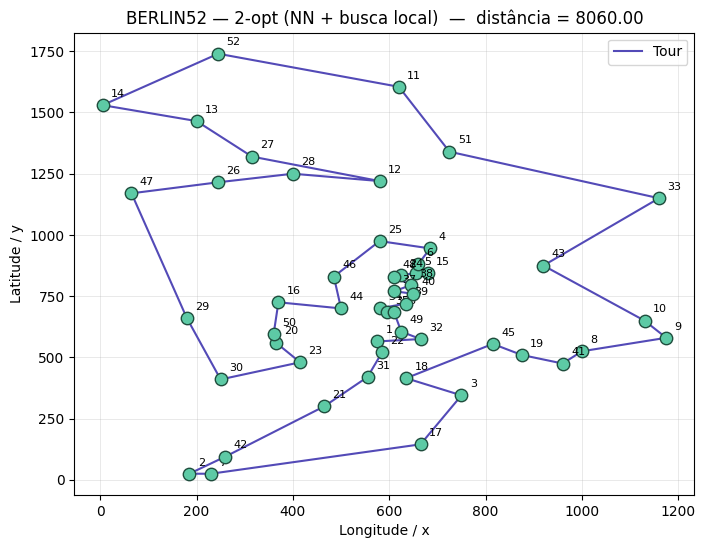

Tempo: 2.49 ms   |   gap vs ótimo: 6.87%


In [ ]:
t0 = time.perf_counter()
tour_2opt_b = dois_opt(tour_nn_b, dist_b)
t_2opt_b = time.perf_counter() - t0
d_2opt_b = plotar_tour(tour_2opt_b, coords_b, dist_b, 'BERLIN52 — 2-opt (NN + busca local)')
print(f'Tempo: {t_2opt_b*1000:.2f} ms   |   gap vs ótimo: {(d_2opt_b-OTIMO_BERLIN52)/OTIMO_BERLIN52*100:.2f}%')

### 9.3 Trajeto 3 — Algoritmo Genético
Para 52 cidades, usamos população maior e mais gerações.

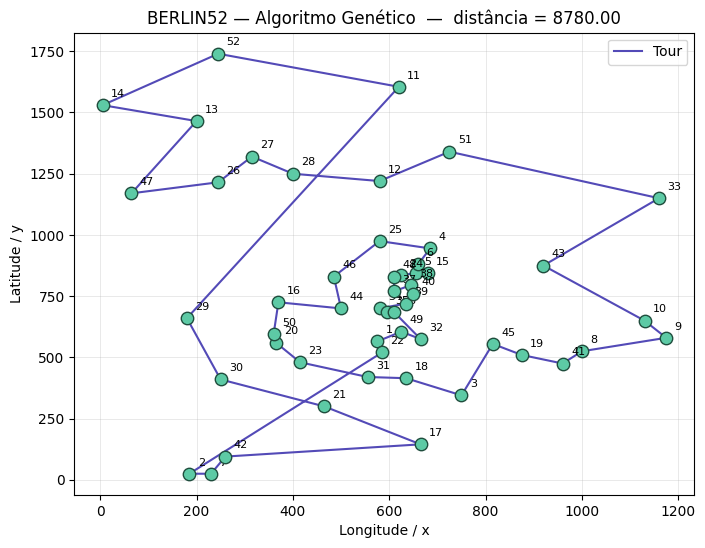

Tempo: 6.66 s   |   gap vs ótimo: 16.41%


In [ ]:
random.seed(42)
t0 = time.perf_counter()
tour_ag_b, hist_m_b, hist_a_b = algoritmo_genetico(n_b, dist_b,
                                                   pop_size=150,
                                                   geracoes=800,
                                                   taxa_cx=0.9,
                                                   taxa_mut=0.03)
t_ag_b = time.perf_counter() - t0
d_ag_b = plotar_tour(tour_ag_b, coords_b, dist_b, 'BERLIN52 — Algoritmo Genético')
print(f'Tempo: {t_ag_b:.2f} s   |   gap vs ótimo: {(d_ag_b-OTIMO_BERLIN52)/OTIMO_BERLIN52*100:.2f}%')

### 9.4 Convergência do AG — berlin52

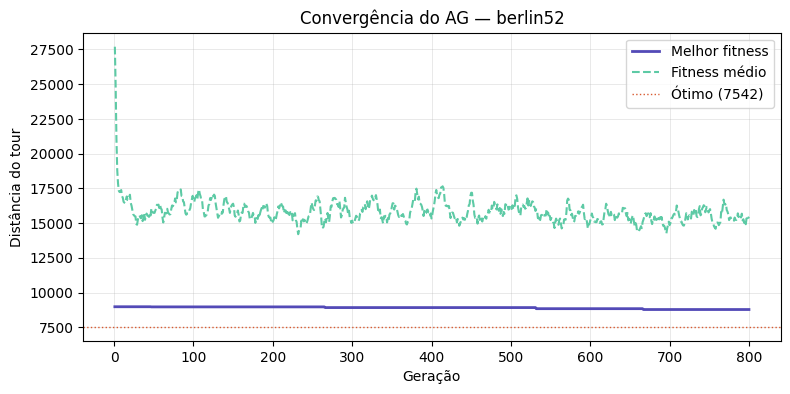

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
geracoes = range(1, len(hist_m_b) + 1)
ax.plot(geracoes, hist_m_b, color='#534AB7', linewidth=2, label='Melhor fitness')
ax.plot(geracoes, hist_a_b, color='#5DCAA5', linewidth=1.5, linestyle='--',
        label='Fitness médio')
ax.axhline(OTIMO_BERLIN52, color='#D85A30', linewidth=1, linestyle=':',
           label=f'Ótimo ({OTIMO_BERLIN52})')
ax.set_xlabel('Geração')
ax.set_ylabel('Distância do tour')
ax.set_title('Convergência do AG — berlin52')
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend()
plt.show()

---
## 10. Repetindo no benchmark `kroA100`
Agora com 100 cidades — instância clássica de Krolak/Felts/Nelson. Ótimo TSPLIB = **21282**.

> Em instâncias deste porte, o AG **puro** (sem refino local) já mostra suas limitações
> frente ao 2-opt. O custo computacional do AG cresce, mas o gap também aumenta —
> por isso, na prática, costuma-se hibridizar AG com busca local (algoritmos meméticos).

In [ ]:
prob_c, nos_c, n_c, dist_c, coords_c = carregar_problema(os.path.join(PASTA, 'kroA100.tsp'))
print(f'Dimensão: {n_c} cidades  |  tipo: {prob_c.edge_weight_type}')
OTIMO_KROA100 = 21282

Dimensão: 100 cidades  |  tipo: EUC_2D


### 10.1 Trajeto 1 — Nearest Neighbor

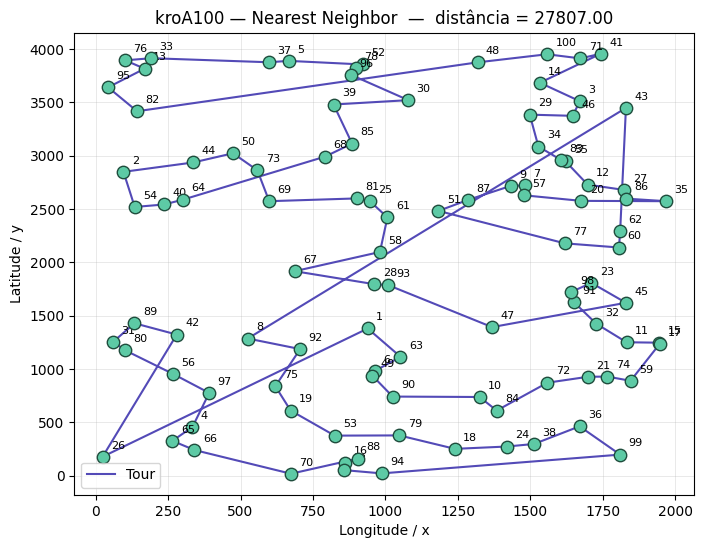

Tempo: 1.57 ms   |   gap vs ótimo: 30.66%


In [ ]:
t0 = time.perf_counter()
tour_nn_c = nearest_neighbor(n_c, dist_c)
t_nn_c = time.perf_counter() - t0
d_nn_c = plotar_tour(tour_nn_c, coords_c, dist_c, 'kroA100 — Nearest Neighbor')
print(f'Tempo: {t_nn_c*1000:.2f} ms   |   gap vs ótimo: {(d_nn_c-OTIMO_KROA100)/OTIMO_KROA100*100:.2f}%')

### 10.2 Trajeto 2 — 2-opt

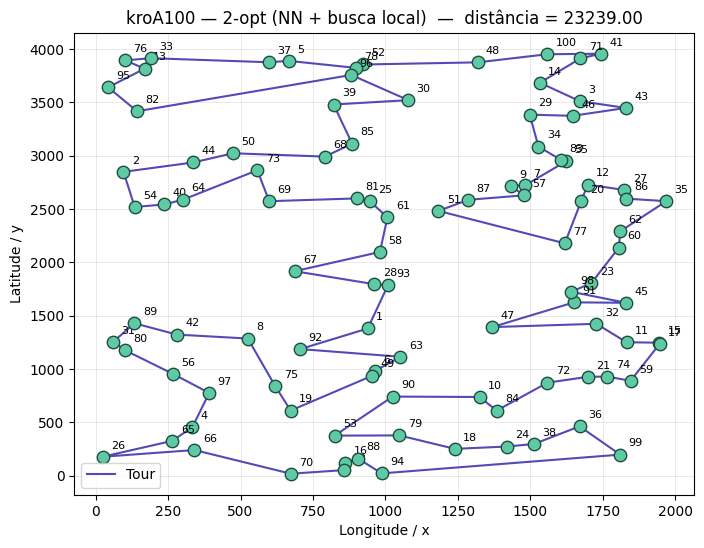

Tempo: 4.81 ms   |   gap vs ótimo: 9.20%


In [ ]:
t0 = time.perf_counter()
tour_2opt_c = dois_opt(tour_nn_c, dist_c)
t_2opt_c = time.perf_counter() - t0
d_2opt_c = plotar_tour(tour_2opt_c, coords_c, dist_c, 'kroA100 — 2-opt (NN + busca local)')
print(f'Tempo: {t_2opt_c*1000:.2f} ms   |   gap vs ótimo: {(d_2opt_c-OTIMO_KROA100)/OTIMO_KROA100*100:.2f}%')

### 10.3 Trajeto 3 — Algoritmo Genético
Para 100 cidades, aumentamos população e gerações. Mesmo assim, o gap será maior
do que o do 2-opt — comportamento esperado para um AG canônico em TSP grande.

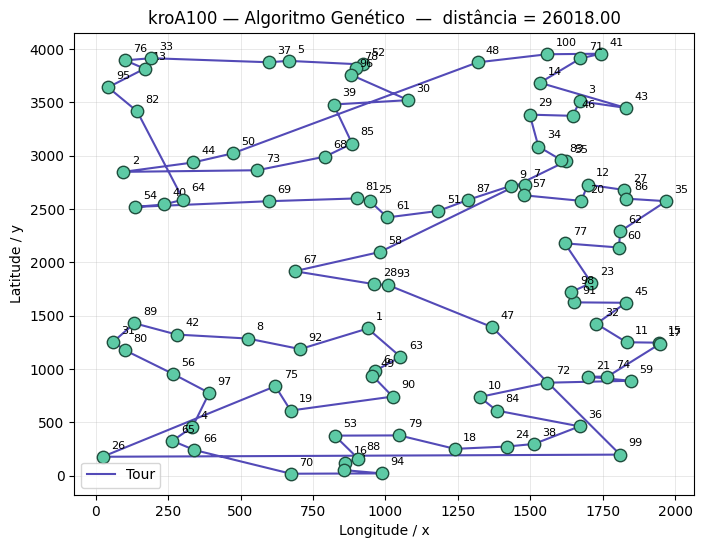

Tempo: 43.58 s   |   gap vs ótimo: 22.25%


In [ ]:
random.seed(42)
t0 = time.perf_counter()
tour_ag_c, hist_m_c, hist_a_c = algoritmo_genetico(n_c, dist_c,
                                                   pop_size=200,
                                                   geracoes=1000,
                                                   taxa_cx=0.9,
                                                   taxa_mut=0.03)
t_ag_c = time.perf_counter() - t0
d_ag_c = plotar_tour(tour_ag_c, coords_c, dist_c, 'kroA100 — Algoritmo Genético')
print(f'Tempo: {t_ag_c:.2f} s   |   gap vs ótimo: {(d_ag_c-OTIMO_KROA100)/OTIMO_KROA100*100:.2f}%')

### 10.4 Convergência do AG — kroA100

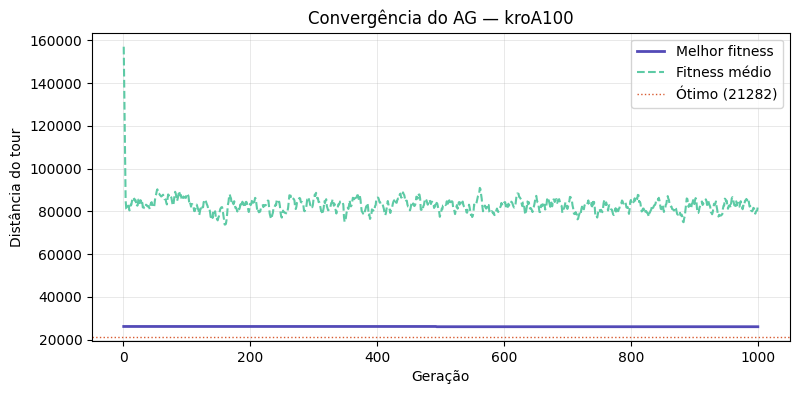

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
geracoes = range(1, len(hist_m_c) + 1)
ax.plot(geracoes, hist_m_c, color='#534AB7', linewidth=2, label='Melhor fitness')
ax.plot(geracoes, hist_a_c, color='#5DCAA5', linewidth=1.5, linestyle='--',
        label='Fitness médio')
ax.axhline(OTIMO_KROA100, color='#D85A30', linewidth=1, linestyle=':',
           label=f'Ótimo ({OTIMO_KROA100})')
ax.set_xlabel('Geração')
ax.set_ylabel('Distância do tour')
ax.set_title('Convergência do AG — kroA100')
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend()
plt.show()

## 11. Tabela final — resumo geral

In [ ]:
resumo = [
    ('burma14',  OTIMO_BURMA14,  'Nearest Neighbor',  d_nn,    t_nn),
    ('burma14',  OTIMO_BURMA14,  '2-opt (NN + LS)',   d_2opt,  t_2opt),
    ('burma14',  OTIMO_BURMA14,  'Algoritmo Genético', d_ag,   t_ag),
    ('berlin52', OTIMO_BERLIN52, 'Nearest Neighbor',  d_nn_b,  t_nn_b),
    ('berlin52', OTIMO_BERLIN52, '2-opt (NN + LS)',   d_2opt_b, t_2opt_b),
    ('berlin52', OTIMO_BERLIN52, 'Algoritmo Genético', d_ag_b, t_ag_b),
    ('kroA100',  OTIMO_KROA100,  'Nearest Neighbor',  d_nn_c,  t_nn_c),
    ('kroA100',  OTIMO_KROA100,  '2-opt (NN + LS)',   d_2opt_c, t_2opt_c),
    ('kroA100',  OTIMO_KROA100,  'Algoritmo Genético', d_ag_c, t_ag_c),
]
print(f"{'Benchmark':<12}{'Ótimo':>8}  {'Algoritmo':<22}{'Distância':>12}{'Tempo (s)':>12}{'Gap (%)':>10}")
print('-' * 76)
atual = None
for bm, ot, nm, d, t in resumo:
    if atual and atual != bm:
        print('-' * 76)
    gap = (d - ot) / ot * 100
    print(f'{bm:<12}{ot:>8}  {nm:<22}{d:>12.2f}{t:>12.3f}{gap:>10.2f}')
    atual = bm
print('-' * 76)

Benchmark      Ótimo  Algoritmo                Distância   Tempo (s)   Gap (%)
----------------------------------------------------------------------------
burma14         3323  Nearest Neighbor           4048.00       0.000     21.82
burma14         3323  2-opt (NN + LS)            3371.00       0.000      1.44
burma14         3323  Algoritmo Genético         3323.00       2.562      0.00
----------------------------------------------------------------------------
berlin52        7542  Nearest Neighbor           8980.00       0.001     19.07
berlin52        7542  2-opt (NN + LS)            8060.00       0.002      6.87
berlin52        7542  Algoritmo Genético         8780.00       6.658     16.41
----------------------------------------------------------------------------
kroA100        21282  Nearest Neighbor          27807.00       0.002     30.66
kroA100        21282  2-opt (NN + LS)           23239.00       0.005      9.20
kroA100        21282  Algoritmo Genético        26018.00  